# Credit Score Classification — EDA & Model Selection

Exploratory data analysis, data cleaning, and baseline model experimentation for a 3-class credit-score classification problem (`Poor` / `Standard` / `Good`) on a noisy, 25,000-row synthetic customer dataset (subset of the public Kaggle "Credit Score Classification" dataset).

This notebook covers:
1. **Cleaning** — placeholder stripping, invalid-value removal, per-customer null imputation, outlier capping, and categorical encoding.
2. **EDA** — distributions and relationships between features and the target.
3. **A baseline model** — XGBoost tuned with Optuna, using a customer-grouped `StratifiedGroupKFold` split so no customer's rows leak between train and test.

The full 7-model comparison (XGBoost, Random Forest, LightGBM, KNN, Extra Trees, Decision Tree, SVM) with MLflow tracking and a persisted Optuna study lives in the OOP training pipeline at [`../pipeline.py`](../pipeline.py), not in this notebook — see the main [README](../README.md) for the full results table.

**Data:** place the raw CSV at `../data/data_A.csv` (see [`../data/README.md`](../data/README.md) for the source and download instructions).

Import libraries and set up display options.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

Load the dataset and display the head.

In [2]:
df = pd.read_csv('../data/data_A.csv', index_col=0)
df.head(5)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.4650,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0000,Good,1023.93,33.4714,20 Years and 5 Months,No,100.1635,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.9850,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0000,Bad,2545.0,33.8106,14 Years and 8 Months,Yes,111.4227,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.1842,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0000,Good,730.64,31.1457,23 Years and 10 Months,NM,135.0443,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.1233,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0000,Standard,932.32,28.4095,27 Years and 0 Months,No,180.6165,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.6058,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0000,Bad,3777.55,28.3734,10 Years and 3 Months,Yes,78.9548,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


Extract initial information about the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22440 non-null  object 
 4   Age                       25000 non-null  object 
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  object 
 8   Monthly_Inhand_Salary     21417 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  
 12  Num_of_Loan               25000 non-null  object 
 13  Type_of_Loan              22172 non-null  object 
 14  Delay_from_

Analyze numerical columns that were loaded with the object dtype (placeholders like `_______` force pandas to read them as strings).

In [4]:
num_cols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

df[num_cols].describe()

,Age,Annual_Income,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance
count,25000,25000,25000,23267,25000,25000,23836,24711
unique,520,12889,127,240,3411,11218,22759,24708
top,38,72524.2,2,19,_,460.46,__10000__,__-333333333333333333333333333__
freq,740,7,3536,1361,518,9,1035,4


Replace empty/placeholder fields with NaN and coerce those columns to numeric.

In [5]:
for c in num_cols:
    df[c] = (df[c].astype(str)
                  .str.replace('_', '', regex=False)
                  .replace({'': np.nan, 'nan': np.nan}))
    df[c] = pd.to_numeric(df[c], errors='coerce')

Find unique values in suspicious categorical columns.

In [6]:
thing = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

for c in thing:
    print(f"Unique values in {c}:")
    print(df[c].unique())
    print()

Unique values in Occupation:
['_______' 'Developer' 'Musician' 'Scientist' 'Entrepreneur' 'Accountant'
 'Journalist' 'Media_Manager' 'Mechanic' 'Writer' 'Doctor' 'Teacher'
 'Lawyer' 'Engineer' 'Architect' 'Manager']

Unique values in Credit_Mix:
['Good' 'Bad' 'Standard' '_']

Unique values in Payment_of_Min_Amount:
['No' 'Yes' 'NM']

Unique values in Payment_Behaviour:
['Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Large_value_payments' 'Low_spent_Large_value_payments'
 '!@9#%8' 'High_spent_Medium_value_payments'
 'High_spent_Small_value_payments']

Unique values in Credit_Score:
['Standard' 'Poor' 'Good']



Replace any invalid input with NaN.

In [7]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

Remove numerical values that are out of range (e.g. Age > 100, Num_of_Loan < 0, etc.).

In [8]:
df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan
df.loc[df['Interest_Rate'] > 50, 'Interest_Rate'] = np.nan
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan

Convert `Credit_History_Age` from the "_ Years and _ Months" string format into a single months value.

In [9]:
def hist_to_months(s):
    if pd.isna(s): return np.nan
    import re
    m = re.search(r'(\d+)\s*Year', str(s)); y = int(m.group(1)) if m else 0
    m = re.search(r'(\d+)\s*Month', str(s)); mo = int(m.group(1)) if m else 0
    return y * 12 + mo
df['Credit_History_Age'] = df['Credit_History_Age'].apply(hist_to_months)

Exploit the fact that rows are grouped by `Customer_ID` to fill null values: borrow the value from another row with the same `Customer_ID` that isn't null.

In [10]:
group = df.groupby('Customer_ID')
for c in ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
          'Num_of_Loan', 'Type_of_Loan', 'Credit_Mix', 'Num_Credit_Inquiries',
          'Credit_History_Age', 'Monthly_Balance']:
    if df[c].dtype == object:
        df[c] = group[c].transform(lambda x: x.ffill().bfill())
    else:
        df[c] = group[c].transform(lambda x: x.fillna(x.median()))

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

...

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

Check for any remaining null values in the dataset.

In [11]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"Count": null_counts, "Percentage (%)": null_pct})
print('Nulls after placeholder cleanup:')
print(null_summary)
print(f"Total rows with any null values: {df.isna().any(axis=1).sum()} out of {len(df)} ({(df.isna().any(axis=1).mean() * 100):.2f}%)")

Nulls after placeholder cleanup:
                         Count  Percentage (%)
Name                      2560         10.2400
Age                         84          0.3400
Occupation                 264          1.0600
Monthly_Inhand_Salary      664          2.6600
Num_Bank_Accounts          335          1.3400
Num_Credit_Card            562          2.2500
Interest_Rate              479          1.9200
Num_of_Loan                139          0.5600
Type_of_Loan              2828         11.3100
Num_of_Delayed_Payment    1889          7.5600
Changed_Credit_Limit       518          2.0700
Num_Credit_Inquiries        72          0.2900
Credit_Mix                1047          4.1900
Credit_History_Age         384          1.5400
Payment_of_Min_Amount     3000         12.0000
Amount_invested_monthly   1164          4.6600
Payment_Behaviour         1852          7.4100
Monthly_Balance             41          0.1600
Total rows with any null values: 12903 out of 25000 (51.61%)


Fill remaining null values with a missingness-dependent rule: columns with less than 5% missing use median (numeric) / mode (categorical) imputation, while columns with more than 5% missing use KNN / predictive imputation.

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier

THRESHOLD = 5.0
MAX_CARDINALITY_FOR_RF = 50

exclude_from_features =  ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns
                    if c not in exclude_from_features]

low_miss_num  = [c for c in numeric_cols     if c in null_pct.index and null_pct[c] < THRESHOLD]
high_miss_num = [c for c in numeric_cols     if c in null_pct.index and null_pct[c] >= THRESHOLD]
low_miss_cat  = [c for c in categorical_cols if c in null_pct.index and null_pct[c] < THRESHOLD]
high_miss_cat = [c for c in categorical_cols if c in null_pct.index and null_pct[c] >= THRESHOLD]

if 'Type_of_Loan' in null_pct.index:
    df['Type_of_Loan'] = (df.groupby('Customer_ID')['Type_of_Loan'].transform(lambda x: x.ffill().bfill()))
    df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')

for c in low_miss_num:
    df[c] = df[c].fillna(df[c].median())
for c in low_miss_cat:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

if high_miss_num:
    knn_cols = list(numeric_cols)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[knn_cols])
    imputed = scaler.inverse_transform(KNNImputer(n_neighbors=5, weights='distance').fit_transform(scaled))
    imputed_df = pd.DataFrame(imputed, columns=knn_cols, index=df.index)
    for c in high_miss_num:
        df[c] = imputed_df[c]

feature_cols_base = [c for c in df.columns if c not in exclude_from_features]

for c in high_miss_cat:
    known, unknown = df[df[c].notna()], df[df[c].isna()]
    if unknown.empty:
        continue

    if known[c].nunique() > MAX_CARDINALITY_FOR_RF:
        print(f"{c}: {known[c].nunique()} unique values — too high for RF, using mode instead")
        df[c] = df[c].fillna(known[c].mode().iloc[0])
        continue

    feature_cols = [col for col in feature_cols_base if col != c]
    model_df = df[feature_cols].copy()
    for col in model_df.select_dtypes(include=['object', 'category']).columns:
        model_df[col] = LabelEncoder().fit_transform(model_df[col].fillna('Missing').astype(str))
    for col in model_df.select_dtypes(include=[np.number]).columns:
        model_df[col] = model_df[col].fillna(model_df[col].median())

    X_known, X_unknown = model_df.loc[known.index], model_df.loc[unknown.index]
    target_encoder = LabelEncoder()
    y_known_enc = target_encoder.fit_transform(known[c].astype(str))

    clf = RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=5,
        n_jobs=2, random_state=42,
    )
    clf.fit(X_known, y_known_enc)
    df.loc[unknown.index, c] = target_encoder.inverse_transform(clf.predict(X_unknown))

print("\nRemaining nulls:", df.isnull().sum().sum())

C:\Users\reyhan\AppData\Local\Temp\ipykernel_15888\703999497.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Type_of_Loan'] = (df.groupby('Customer_ID')['Type_of_Loan'].transform(lambda x: x.ffill().bfill()))



Remaining nulls: 2560


Check for any null values that survived the imputation step.

In [13]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"Count": null_counts, "Percentage (%)": null_pct})
print('Nulls after placeholder cleanup:')
print(null_summary)
print(f"Total rows with any null values: {df.isna().any(axis=1).sum()} out of {len(df)} ({(df.isna().any(axis=1).mean() * 100):.2f}%)")

Nulls after placeholder cleanup:
      Count  Percentage (%)
Name   2560         10.2400
Total rows with any null values: 2560 out of 25000 (10.24%)


Drop columns that aren't needed as features (identifiers like `ID`, `Name`, `SSN`).

In [14]:
df = df.drop(columns=['ID', 'Name', 'SSN'])

Render the current state of the dataset.

In [15]:
df

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x936d,March,33.0000,Engineer,100433.5800,8074.4650,1.0000,5.0000,10.0000,2.0000,"Student Loan, and Debt Consolidation Loan",13,4.0000,12.5900,3.0000,Good,1023.9300,33.4714,245.0000,No,100.1635,758.0705,Low_spent_Medium_value_payments,229.2125,Standard
1,CUS_0x9a29,August,25.0000,Developer,33119.8200,3024.9850,10.0000,5.0000,32.0000,5.0000,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18.0000,15.7900,10.0000,Bad,2545.0000,33.8106,176.0000,Yes,111.4227,136.3629,Low_spent_Small_value_payments,370.6075,Poor
2,CUS_0x12a9,April,44.0000,Media_Manager,44822.2100,3555.1842,1.0000,4.0000,2.0000,4.0000,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8.0000,4.0300,0.0000,Good,730.6400,31.1457,286.0000,No,135.0443,256.4743,Low_spent_Medium_value_payments,243.9998,Standard
3,CUS_0x3bad,June,29.0000,Musician,142081.4800,11771.1233,6.0000,6.0000,15.0000,3.0000,"Personal Loan, Not Specified, and Mortgage Loan",29,20.0000,8.2100,4.0000,Standard,932.3200,28.4095,324.0000,No,180.6165,423.9613,Low_spent_Small_value_payments,862.5346,Standard
4,CUS_0xa3e1,January,45.0000,Scientist,19267.2700,1374.6058,10.0000,8.0000,25.0000,6.0000,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,18.4279,19.7000,6.0000,Bad,3777.5500,28.3734,123.0000,Yes,78.9548,133.5685,Low_spent_Small_value_payments,214.9373,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUS_0x3854,June,21.0000,Manager,40100.4500,3280.7042,0.0000,4.0000,7.0000,0.0000,Not Specified,4,12.0000,2.1600,4.0000,Good,821.7400,31.3988,390.5000,No,0.0000,119.1134,High_spent_Small_value_payments,468.9571,Good
24996,CUS_0xc80,July,31.0000,Musician,48706.1000,4052.8417,5.0000,3.0000,7.0000,3.0000,"Student Loan, Payday Loan, and Personal Loan",18,10.0000,13.0200,7.0000,Standard,1083.7600,29.5668,208.0000,Yes,107.1526,156.6731,High_spent_Medium_value_payments,391.4585,Standard
24997,CUS_0x16c4,April,17.0000,Mechanic,8473.7950,512.1496,4.0000,7.0000,7.0000,3.0000,"Mortgage Loan, Personal Loan, and Not Specified",20,14.0000,12.7800,7.0000,Standard,1040.1400,38.1767,209.0000,Yes,16.7988,41.3606,Low_spent_Small_value_payments,283.0555,Standard
24998,CUS_0x8a50,January,23.0000,Developer,68281.1800,5920.0983,4.0000,3.0000,2.0000,2.0000,"Not Specified, and Payday Loan",6,11.0000,9.4900,2.0000,Good,476.1800,32.6753,209.0000,No,5851.0000,136.3629,High_spent_Medium_value_payments,591.9765,Good


## Handling outliers

Check for columns with outlier values.

In [16]:
def detect_outliers_iqr(df, cols=None, multiplier=1.5):

    if cols is None:
        cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if df[c].nunique() > 2]

    rows = []
    for c in cols:
        q1, q3 = df[c].quantile(0.05), df[c].quantile(0.95)
        iqr = q3 - q1
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr

        mask = (df[c] < lower) | (df[c] > upper)
        n_outliers = mask.sum()

        if n_outliers > 0:
            rows.append({
                'Column': c,
                'Outlier_Count': n_outliers,
                'Outlier_Pct': round(n_outliers / len(df) * 100, 2),
                'Lower_Bound': round(lower, 2),
                'Upper_Bound': round(upper, 2),
                'Min': df[c].min(),
                'Max': df[c].max(),
            })

    if(len(rows) > 0):
        return (pd.DataFrame(rows)
                  .sort_values('Outlier_Count', ascending=False)
                  .reset_index(drop=True))
    else:
        return False

outlier_summary = detect_outliers_iqr(df)
print(outlier_summary)
if(outlier_summary is not False):
    print('\nColumns with outliers:', outlier_summary['Column'].tolist())

                    Column  Outlier_Count  Outlier_Pct  Lower_Bound  \
0  Amount_invested_monthly           1035       4.1400   -1469.9900   
1      Total_EMI_per_month            857       3.4300    -669.6600   
2     Num_Credit_Inquiries            422       1.6900     -19.5000   
3            Annual_Income            265       1.0600 -177645.5300   
4   Num_of_Delayed_Payment            249       1.0000     -29.5000   
5              Num_of_Loan            113       0.4500     -12.0000   
6          Monthly_Balance              4       0.0200    -859.2700   

   Upper_Bound                               Min           Max  
0    2536.5100                            0.0000    10000.0000  
1    1116.1000                            0.0000    82236.0000  
2      32.5000                            0.0000     2597.0000  
3  322472.6900                         7005.9300 24188807.0000  
4      54.5100                            0.0000     4388.0000  
5      20.0000                           

Convert suspicious negative values to their absolute value.

In [17]:
df['Delay_from_due_date'] = df['Delay_from_due_date'].abs()
df['Monthly_Balance'] = df['Monthly_Balance'].abs()
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].abs()
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].abs()

Cap outliers at the 5th and 95th percentiles.

In [18]:
def cap_outliers_percentile(df, cols, lower_pct=0.05, upper_pct=0.95):
    for c in cols:
        lower = df[c].quantile(lower_pct)
        upper = df[c].quantile(upper_pct)
        before_min, before_max = df[c].min(), df[c].max()

        df[c] = df[c].clip(lower=lower, upper=upper)

        print(f"{c}: [{before_min:.2f}, {before_max:.2f}] capped at [{lower:.2f}, {upper:.2f}]")

    return df

cap = ['Amount_invested_monthly', 'Monthly_Balance', 'Total_EMI_per_month', 'Outstanding_Debt', 'Delay_from_due_date', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Changed_Credit_Limit', 'Num_of_Delayed_Payment', 'Num_of_Loan', 'Num_Credit_Card', 'Age']
df = cap_outliers_percentile(df, cap)

Amount_invested_monthly: [0.00, 10000.00] capped at [32.45, 1034.07]
Monthly_Balance: [0.90, 333333333333333314856026112.00] capped at [174.22, 863.42]
Total_EMI_per_month: [0.00, 82236.00] capped at [0.00, 446.44]
Outstanding_Debt: [0.23, 4998.07] capped at [116.91, 4073.41]
Delay_from_due_date: [0.00, 67.00] capped at [3.00, 54.00]
Annual_Income: [7005.93, 24188807.00] capped at [9898.80, 134928.36]
Monthly_Inhand_Salary: [303.65, 15167.18] capped at [858.18, 10827.83]
Num_Credit_Inquiries: [0.00, 2597.00] capped at [0.00, 13.00]
Changed_Credit_Limit: [0.01, 36.29] capped at [1.39, 23.44]
Num_of_Delayed_Payment: [0.00, 4388.00] capped at [2.00, 23.00]
Num_of_Loan: [0.00, 1482.00] capped at [0.00, 8.00]
Num_Credit_Card: [0.00, 16.00] capped at [3.00, 10.00]
Age: [14.00, 95.00] capped at [17.00, 52.00]


Check for any remaining outliers.

In [19]:
outlier_summary = detect_outliers_iqr(df)
print(outlier_summary)
if(outlier_summary is not False):
    print('\nColumns with outliers:', outlier_summary['Column'].tolist())

False


## Encode categorical columns

In [20]:
credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score'] = df['Credit_Score'].map(credit_score_map)

In [21]:
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map)


In [22]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

In [23]:
spend_map = {'Low': 0, 'High': 1}
value_map = {'Small': 0, 'Medium': 1, 'Large': 2}

pb_parts = df['Payment_Behaviour'].str.split('_', n=2, expand=True)
df['Spend_Level'] = pb_parts[0].map(spend_map)
df['Payment_Value'] = pb_parts[2].str.split('_').str[0].map(value_map)
df = df.drop(columns=['Payment_Behaviour'])

In [24]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['Month'] = df['Month'].map(month_map)

Encode `Type_of_Loan` into one `Has_*` flag column per loan type, and `Occupation` into one-hot columns.

In [25]:
import re
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

def parse_loan_types(s):
    if pd.isna(s):
        return []
    cleaned = re.sub(r',\s*and\s+', ', ', s)
    types = [t.strip() for t in cleaned.split(',') if t.strip()]
    return list(set(types))

df['Loan_Type_List'] = df['Type_of_Loan'].apply(parse_loan_types)

mlb = MultiLabelBinarizer()
flag_array = mlb.fit_transform(df['Loan_Type_List'])
flag_cols = [f"Has_{cls.strip().replace(' ', '_').replace('-', '_')}" for cls in mlb.classes_]

loan_flags = pd.DataFrame(flag_array, columns=flag_cols, index=df.index)
df = pd.concat([df, loan_flags], axis=1)

print("Loan types found:", list(mlb.classes_))
print(loan_flags.sum().sort_values(ascending=False))

df = df.drop(columns=['Loan_Type_List', 'Type_of_Loan'])

Loan types found: ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']
Has_Not_Specified              10768
Has_Mortgage_Loan               8033
Has_Credit_Builder_Loan         7988
Has_Payday_Loan                 7963
Has_Home_Equity_Loan            7905
Has_Personal_Loan               7876
Has_Debt_Consolidation_Loan     7748
Has_Student_Loan                7747
Has_Auto_Loan                   7635
dtype: int64


In [26]:
df = pd.get_dummies(df, columns=['Occupation'], prefix='Occupation', drop_first=False)

In [27]:
df.head(5)

,Customer_ID,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Spend_Level,Payment_Value,Has_Auto_Loan,Has_Credit_Builder_Loan,Has_Debt_Consolidation_Loan,Has_Home_Equity_Loan,Has_Mortgage_Loan,Has_Not_Specified,Has_Payday_Loan,Has_Personal_Loan,Has_Student_Loan,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,CUS_0x936d,3,33.0000,100433.5800,8074.4650,1.0000,5.0000,10.0000,2.0000,13,4.0000,12.5900,3.0000,2,1023.9300,33.4714,245.0000,0,100.1635,758.0705,229.2125,1,0,1,0,0,1,0,0,0,0,0,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,CUS_0x9a29,8,25.0000,33119.8200,3024.9850,10.0000,5.0000,32.0000,5.0000,50,18.0000,15.7900,10.0000,0,2545.0000,33.8106,176.0000,1,111.4227,136.3629,370.6075,0,0,0,0,0,1,1,1,1,0,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,CUS_0x12a9,4,44.0000,44822.2100,3555.1842,1.0000,4.0000,2.0000,4.0000,14,8.0000,4.0300,0.0000,2,730.6400,31.1457,286.0000,0,135.0443,256.4743,243.9998,1,0,1,0,1,1,0,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,CUS_0x3bad,6,29.0000,134928.3600,10827.8300,6.0000,6.0000,15.0000,3.0000,29,20.0000,8.2100,4.0000,1,932.3200,28.4095,324.0000,0,180.6165,423.9613,862.5346,1,0,0,0,0,0,0,1,1,0,1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,CUS_0xa3e1,1,45.0000,19267.2700,1374.6058,10.0000,8.0000,25.0000,6.0000,33,18.4279,19.7000,6.0000,0,3777.5500,28.3734,123.0000,1,78.9548,133.5685,214.9373,0,0,0,1,0,0,1,0,1,1,0,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


Save the cleaned dataset.

In [28]:
OUT_PATH = '../data/data_A_cleaned.csv'
df.to_csv(OUT_PATH, index=False)

## Exploratory Data Analysis

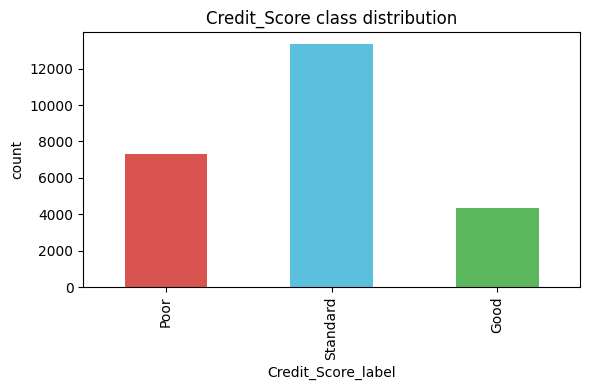

Credit_Score_label
Poor       0.2921
Standard   0.5332
Good       0.1747
Name: proportion, dtype: float64


In [29]:
target_map = {0: 'Poor', 1: 'Standard', 2: 'Good'}
df['Credit_Score_label'] = df['Credit_Score'].map(target_map)
order = ['Poor', 'Standard', 'Good']

fig, ax = plt.subplots(figsize=(6, 4))
df['Credit_Score_label'].value_counts().reindex(order).plot(kind='bar', ax=ax, color=['#d9534f','#5bc0de','#5cb85c'])
ax.set_title('Credit_Score class distribution')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

print(df['Credit_Score_label'].value_counts(normalize=True).reindex(order))

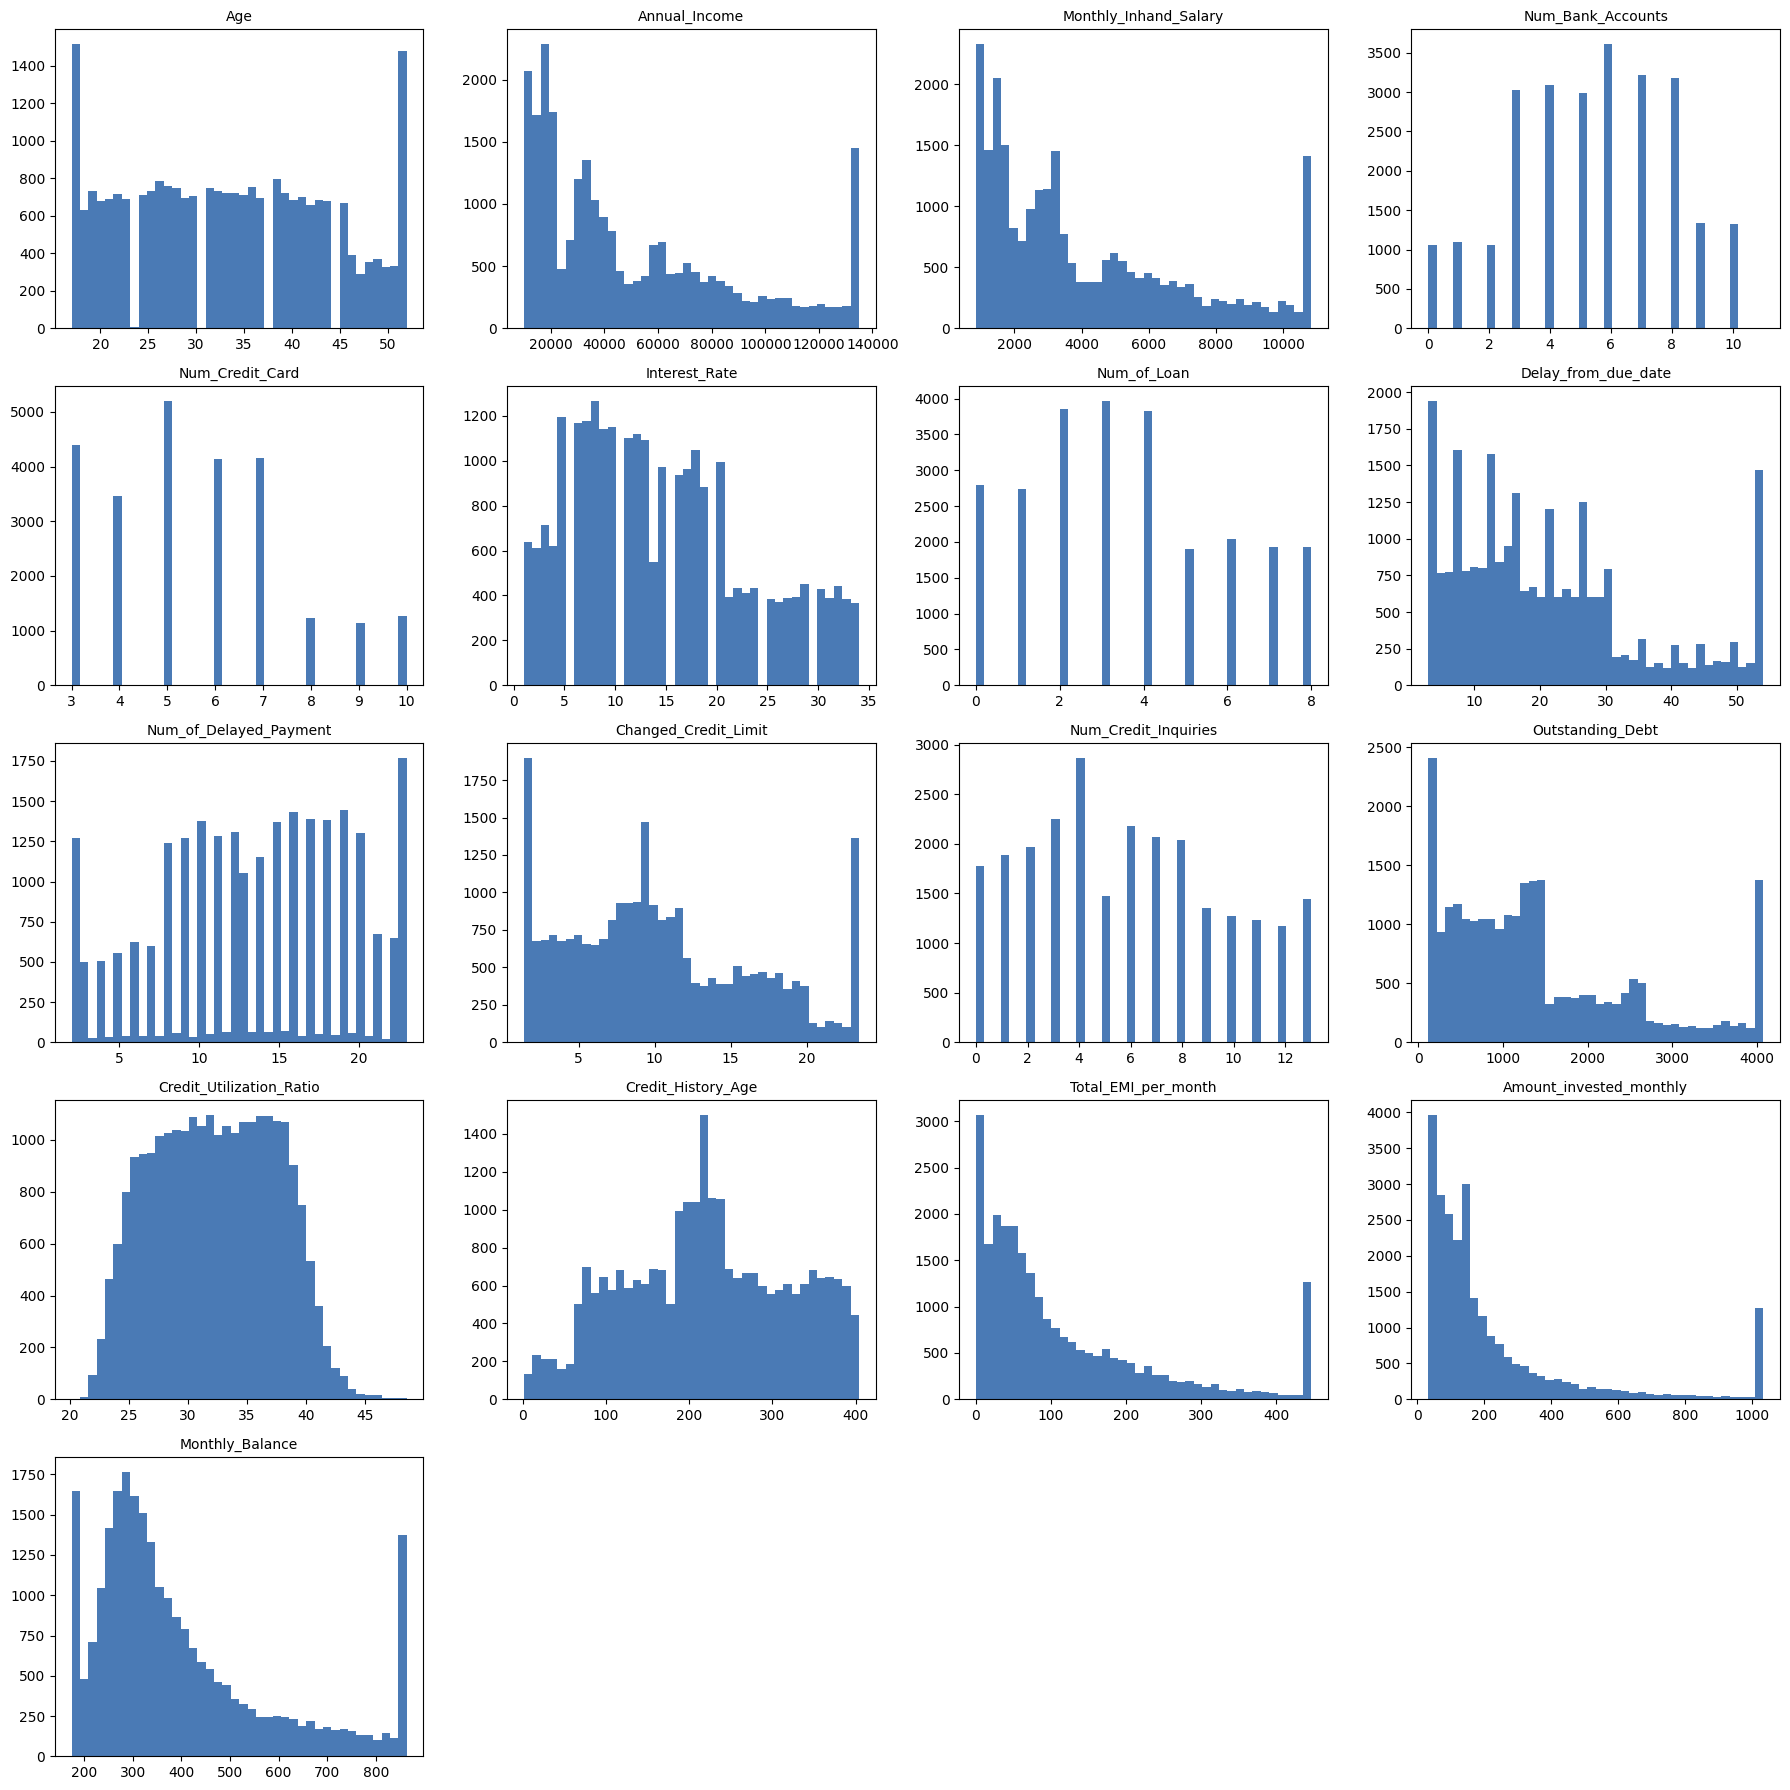

In [30]:
continuous_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=40, color='#4a7ab5')
    axes[i].set_title(col, fontsize=10)
for j in range(len(continuous_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

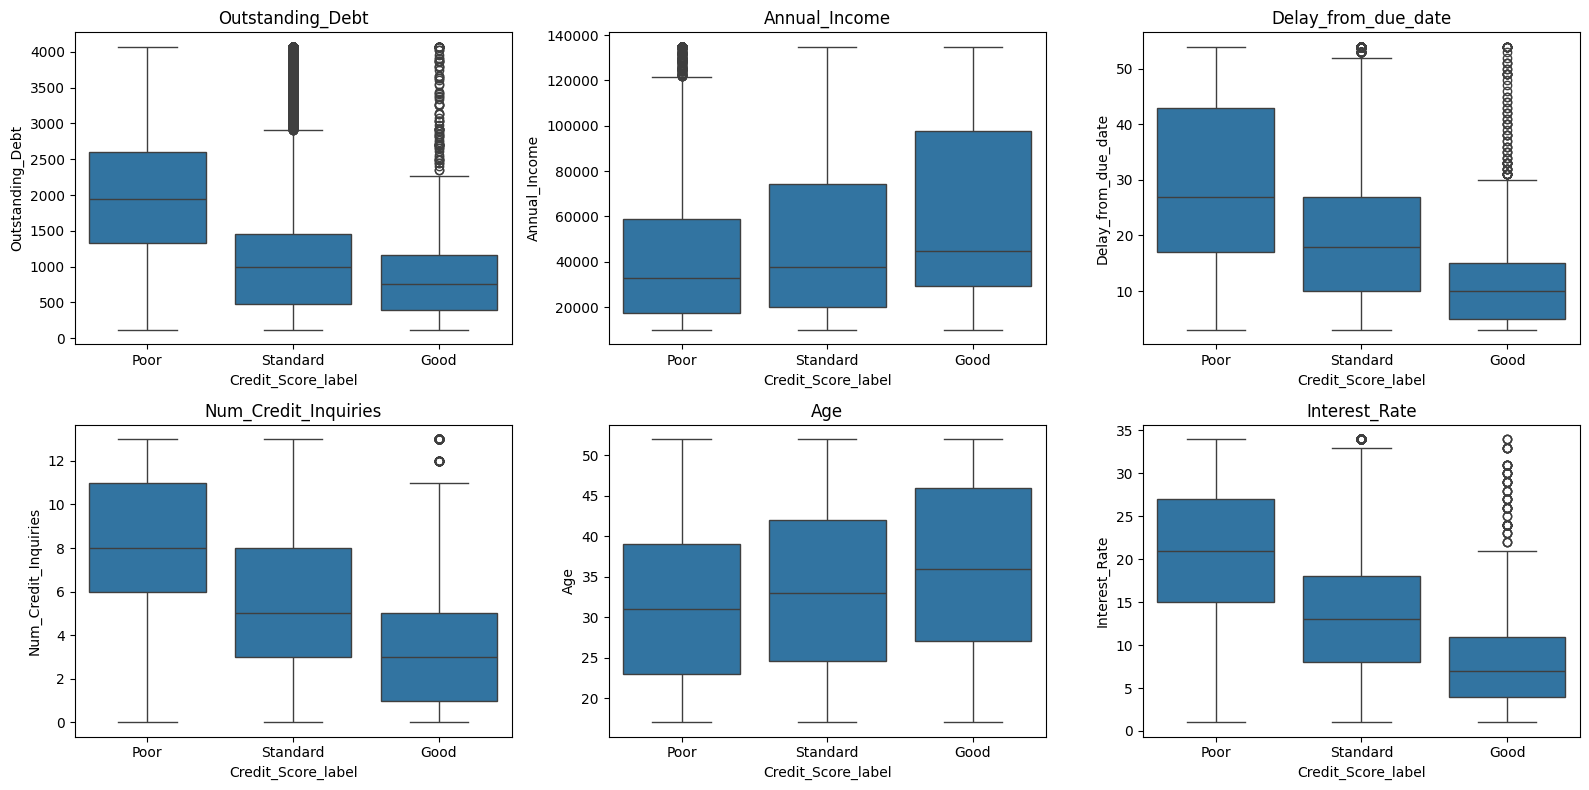

In [31]:
key_numeric = ['Outstanding_Debt', 'Annual_Income', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Age', 'Interest_Rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    sns.boxplot(data=df, x='Credit_Score_label', y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

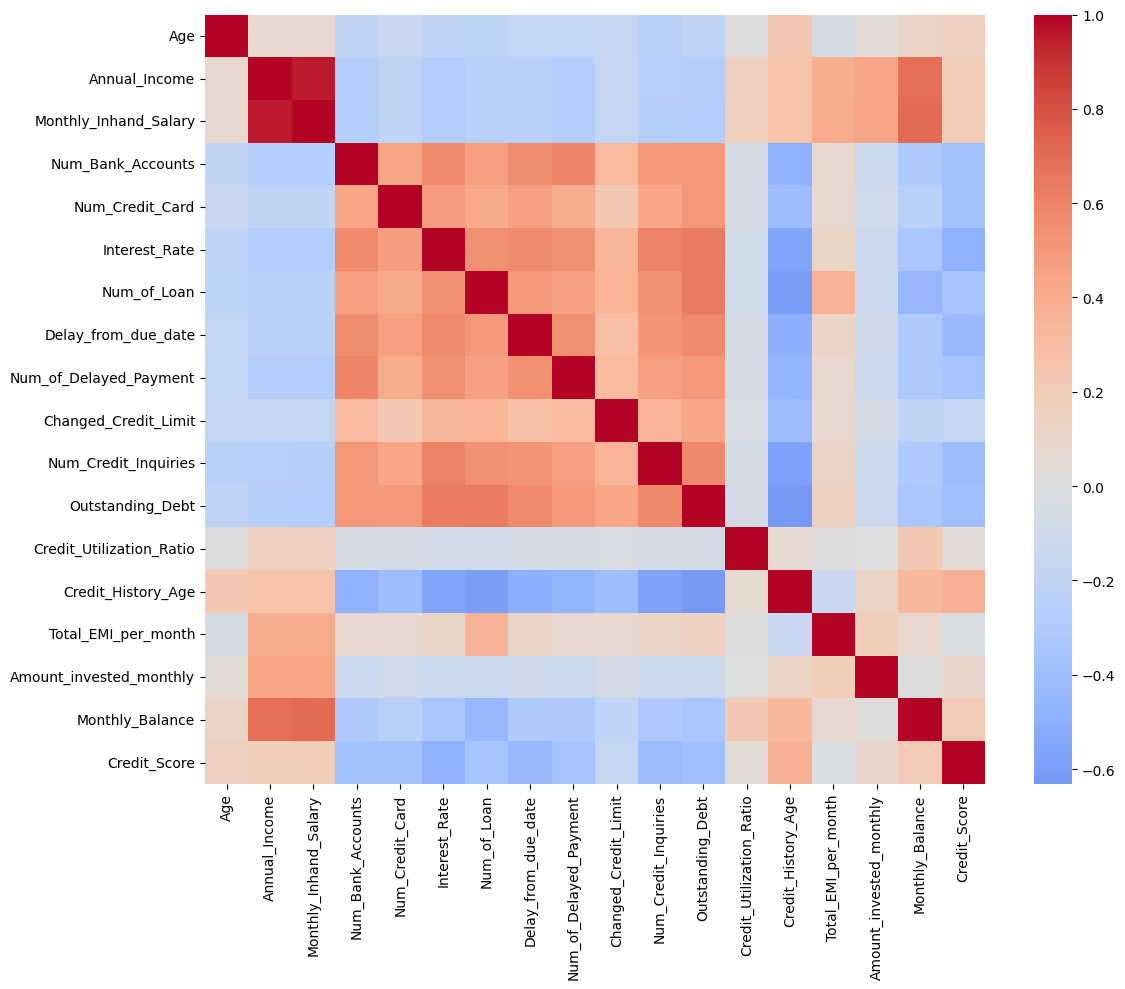

Interest_Rate              -0.4733
Delay_from_due_date        -0.4313
Num_Credit_Inquiries       -0.4166
Outstanding_Debt           -0.3900
Credit_History_Age          0.3809
Num_Bank_Accounts          -0.3795
Num_Credit_Card            -0.3745
Num_of_Delayed_Payment     -0.3615
Num_of_Loan                -0.3567
Monthly_Balance             0.2142
Monthly_Inhand_Salary       0.1965
Annual_Income               0.1950
Changed_Credit_Limit       -0.1604
Age                         0.1563
Amount_invested_monthly     0.0976
Credit_Utilization_Ratio    0.0446
Total_EMI_per_month        -0.0295
Name: Credit_Score, dtype: float64


In [32]:
corr = df[continuous_cols + ['Credit_Score']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
plt.tight_layout()
plt.show()

print(corr['Credit_Score'].drop('Credit_Score').sort_values(key=abs, ascending=False))

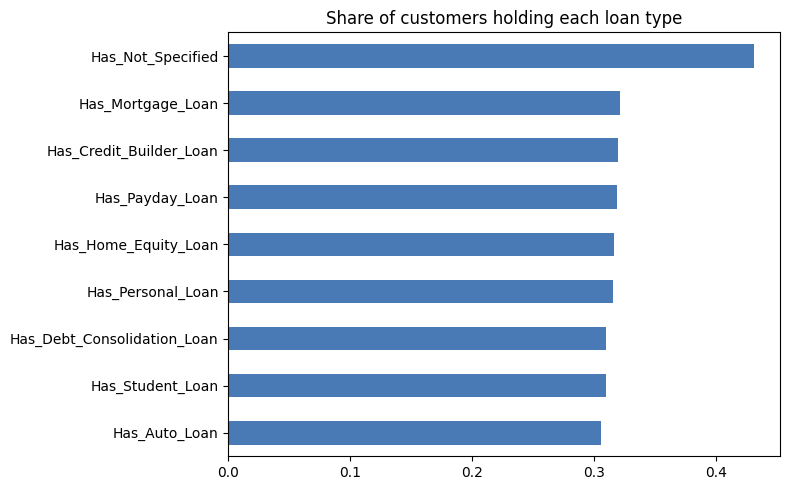

In [33]:
has_cols = [c for c in df.columns if c.startswith('Has_')]

fig, ax = plt.subplots(figsize=(8, 5))
df[has_cols].mean().sort_values().plot(kind='barh', ax=ax, color='#4a7ab5')
ax.set_title('Share of customers holding each loan type')
plt.tight_layout()
plt.show()

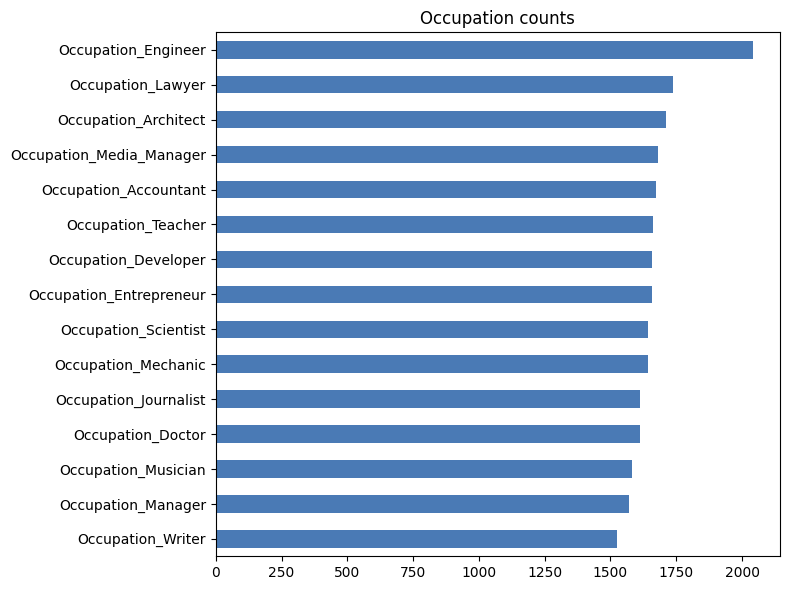

In [34]:
occ_cols = [c for c in df.columns if c.startswith('Occupation_')]

fig, ax = plt.subplots(figsize=(8, 6))
df[occ_cols].sum().sort_values().plot(kind='barh', ax=ax, color='#4a7ab5')
ax.set_title('Occupation counts')
plt.tight_layout()
plt.show()

# Model Selection & Tuning

## Data preparation

Split the dataset into train/test with `StratifiedGroupKFold`, grouped by `Customer_ID`, so a customer never appears in both splits (prevents leakage).

In [35]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

df = pd.read_csv('../data/data_A_cleaned.csv')

target_col = 'Credit_Score'
id_col = 'Customer_ID'

id_like_cols = [c for c in ['ID', 'Name', 'SSN'] if c in df.columns]
X = df.drop(columns=[target_col, id_col] + id_like_cols)
y = df[target_col]
groups = df[id_col]

n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

overlap = set(groups_train) & set(groups_test)
assert len(overlap) == 0, f"Leakage! {len(overlap)} customers appear in both sets"

print(f"Train: {X_train.shape[0]} rows, {groups_train.nunique()} unique customers")
print(f"Test:  {X_test.shape[0]} rows, {groups_test.nunique()} unique customers")

print("Class balance")
print(pd.DataFrame({
    'full': y.value_counts(normalize=True),
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True),
}))

Train: 19983 rows, 8966 unique customers
Test:  5017 rows, 2286 unique customers
Class balance
               full  train   test
Credit_Score                     
1            0.5332 0.5341 0.5298
0            0.2921 0.2929 0.2886
2            0.1747 0.1730 0.1816


## XGBoost with Optuna Hyperparameter Tuning

Uses Optuna to search over XGBoost hyperparameters. The objective is evaluated with 3-fold StratifiedGroupKFold CV on the training set to avoid customer leakage, then the best params are used to train a final model on all of `X_train` and evaluated on `X_test`.

In [36]:
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr = X_train.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)
g_tr = groups_train.reset_index(drop=True)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=50),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "objective":        "multi:softprob",
        "num_class":        3,
        "eval_metric":      "mlogloss",
        "tree_method":      "hist",
        "random_state":     42,
        "n_jobs":           -1,
    }

    cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_tr, y_tr, groups=g_tr):
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr.iloc[train_idx], y_tr.iloc[train_idx],
            eval_set=[(X_tr.iloc[val_idx], y_tr.iloc[val_idx])],
            verbose=False,
        )
        preds = model.predict(X_tr.iloc[val_idx])
        scores.append(f1_score(y_tr.iloc[val_idx], preds, average="macro"))

    return sum(scores) / len(scores)

study = optuna.create_study(direction="maximize", study_name="xgb_credit_score")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest macro F1 (CV): {study.best_value:.4f}")
print("Best params:", study.best_params)

C:\Users\reyhan\anaconda3\envs\new_model_deployment\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.664943:   0%|          | 0/50 [00:06<?, ?it/s]

Best trial: 0. Best value: 0.664943:   2%|▏         | 1/50 [00:06<05:34,  6.82s/it]

Best trial: 0. Best value: 0.664943:   2%|▏         | 1/50 [00:37<05:34,  6.82s/it]

...

Best trial: 37. Best value: 0.677893:  98%|█████████▊| 49/50 [07:59<00:10, 10.65s/it]

Best trial: 37. Best value: 0.677893:  98%|█████████▊| 49/50 [08:10<00:10, 10.65s/it]

Best trial: 37. Best value: 0.677893: 100%|██████████| 50/50 [08:10<00:00, 10.56s/it]

Best trial: 37. Best value: 0.677893: 100%|██████████| 50/50 [08:10<00:00,  9.80s/it]


Best macro F1 (CV): 0.6779
Best params: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.005795863980643436, 'subsample': 0.9118777470929532, 'colsample_bytree': 0.9134090006103802, 'min_child_weight': 10, 'reg_alpha': 2.1278597178904985, 'reg_lambda': 2.2608334537116685e-08, 'gamma': 4.1371478337408485}


Train the final model on all training data using the best hyperparameters found by Optuna.

Test Set Performance
              precision    recall  f1-score   support

        Poor       0.72      0.62      0.67      1448
    Standard       0.73      0.77      0.75      2658
        Good       0.61      0.65      0.63       911

    accuracy                           0.70      5017
   macro avg       0.69      0.68      0.68      5017
weighted avg       0.71      0.70      0.70      5017

Macro F1: 0.6816


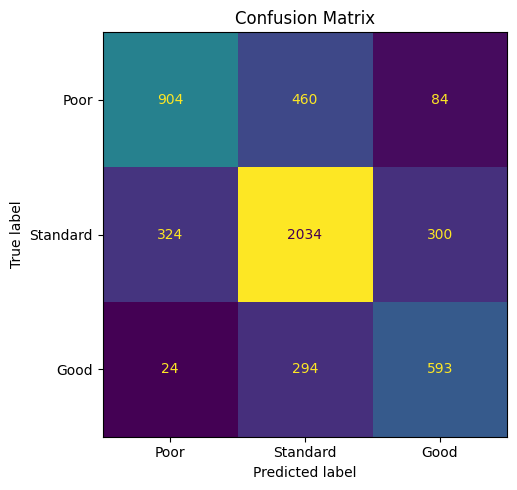

In [37]:
best_params = {**study.best_params,
               "objective":    "multi:softprob",
               "num_class":    3,
               "eval_metric":  "mlogloss",
               "tree_method":  "hist",
               "random_state": 42,
               "n_jobs":       -1}

XGB_model = xgb.XGBClassifier(**best_params)
XGB_model.fit(X_train, y_train, verbose=False)

y_pred = XGB_model.predict(X_test)

label_names = ["Poor", "Standard", "Good"]
print("Test Set Performance")
print(classification_report(y_test, y_pred, target_names=label_names))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_names, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

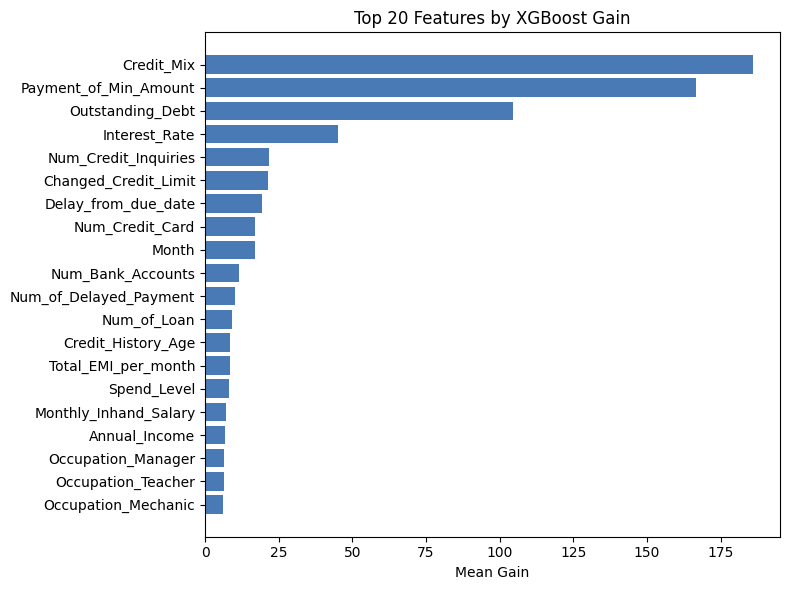

In [38]:
# Feature importance (gain-based)
importances = XGB_model.get_booster().get_score(importance_type="gain")
imp_df = (pd.Series(importances)
            .sort_values(ascending=False)
            .head(20)
            .reset_index())
imp_df.columns = ["Feature", "Gain"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["Feature"][::-1], imp_df["Gain"][::-1], color="#4a7ab5")
ax.set_title("Top 20 Features by XGBoost Gain")
ax.set_xlabel("Mean Gain")
plt.tight_layout()
plt.show()

In [39]:
XGB_model.save_model('xgb_credit_score_model.json')
print('XGBoost saved → xgb_credit_score_model.json')

XGBoost saved → xgb_credit_score_model.json


## Conclusion

After cleaning, the dataset yields 46 engineered features from 20,000 training rows and 5,000 held-out rows, split so no `Customer_ID` appears in both. A single Optuna-tuned XGBoost model trained here reaches a reasonable macro-F1 baseline, but the class imbalance (the `Good` class is roughly 17-19% of rows) keeps recall on the minority classes lower than on `Standard`.

The production pipeline (`../pipeline.py`) builds on this notebook's cleaning logic as reusable classes (`CreditDataPreprocessor`, `DataSplitter`), adds SMOTE oversampling inside each training fold, and compares 7 model families with MLflow-tracked, Optuna-pruned hyperparameter search. LightGBM was the eventual champion at macro-F1 ≈ 0.683 on the held-out test set — see the main [README](../README.md) for the full per-model results and per-class breakdown.